<a href="https://colab.research.google.com/github/zamoralinokevin-eng/Maestria-en-IA/blob/main/Sesion12_Evaluacion_Analisis_Descriptivo_271753.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** Kevin Josue Zamora Lino
- **Matrícula:**271753

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [5]:
# 1.1 — Calcula la media, mediana y moda de la columna 'price'.
media = df["price"].mean()
mediana = df["price"].median()
moda = df["price"].mode()
print(f"La media es: {media:,.2f}")
print(f"La mediana es: {mediana:,.2f}")
print(f"La moda es: {moda}")




La media es: 152.72
La mediana es: 106.00
La moda es: 0    100
Name: price, dtype: int64


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:_La media y mediana si divergen 46 unidad aproximadamente por lo que esta divergencia indica que es probable que exista asimentria o valores extremos en la columna "price"

---
## Actividad 2 — Dispersión (20 pts)

In [8]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.
rango = df["price"].max() - df["price"].min()
varianza = df["price"].var()
desviacion_estandar = df["price"].std()
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
print(f"El valor maximo es: {df["price"].max():,.2f}")
print(f"EL rango es: {rango:,.2f}")
print(f"La varianza es: {varianza:,.2f}")
print(f"La desviacion estandar es: {desviacion_estandar:,.2f}")
print(f"El primer cuartil es: {Q1:,.2f}")
print(f"El tercer cuartil es: {Q3:,.2f}")
print(f"El rango intercuartilico es: {IQR:,.2f}")




El valor maximo es: 10,000.00
EL rango es: 10,000.00
La varianza es: 57,674.03
La desviacion estandar es: 240.15
El primer cuartil es: 69.00
El tercer cuartil es: 175.00
El rango intercuartilico es: 106.00


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta:_El valor que parece mas representativo de la dispersion tipica es el rango intercuartilico. Esto debido a que el rango normal considera la diferencia entre el maximo y el minimo y en este caso tenemos un maximo de 10,000 que comparado con la media, es probable que sea un outlier. En el caso del Rango intercuartilico, el valor es el mismo que la mediana y aparte se enfoca en el 50% de los datos centrales de la columna "price", dejando a un lado el 25% de los valores mas bajos y altos.

---
## Actividad 3 — Forma (20 pts)

In [30]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.
asimetria = df["price"].skew()
curtosis = df["price"].kurt()
print(f"La asimetria es: {asimetria:,.2f}")
print(f"La curtosis es: {curtosis:,.2f}")


La asimetria es: 19.12
La curtosis es: 585.67


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta:_Anteriormente, se encontró que la media es mayor a la mediana. Ahora, con el valor positivo de la asimetria, se corrobora que la distribucion de los datos se inclina hacia la derecha, es decir la cola larga esta hacia la derecha. En el caso de la curtosis, indica una cola de distribucion extremadamente pesada comparada con la distribucion normal, es decir, valores muy alejados del centro, como lo vimos previamente con el valor maximo.
La relacion que espero entre estos valores y la proxima etapa del curso, es que en el histograma, aparezca un bin con un valor muy alto a diferencia de otros bines y con el boxplot espero valores que esten por fuera de los "bigotes" representando los outliers.

---
## Actividad 4 — Visualización (30 pts)

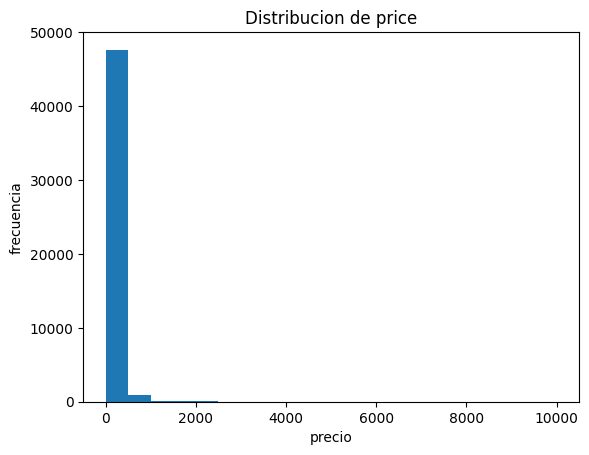

In [28]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.
df["price"].plot(kind="hist", bins = 20, title= "Distribucion de price")
plt.xlabel("precio")
plt.ylabel("frecuencia")
plt.show()

#elegi bins=20 porque al parecer existen 2 grupos principales,
#el primero con la mayor frecuencia de datos (>45,000) y precio entre 0-500
#el segundo con una frecuencia <2,000 y valores entre 500-10,000


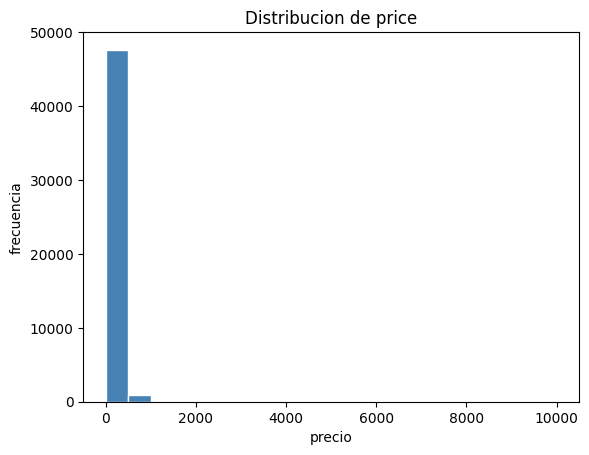

In [29]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.
plt.hist(df["price"], bins= 20, color= "steelblue", edgecolor = "white")
plt.title("Distribucion de price")
plt.xlabel("precio")
plt.ylabel("frecuencia")
plt.show()


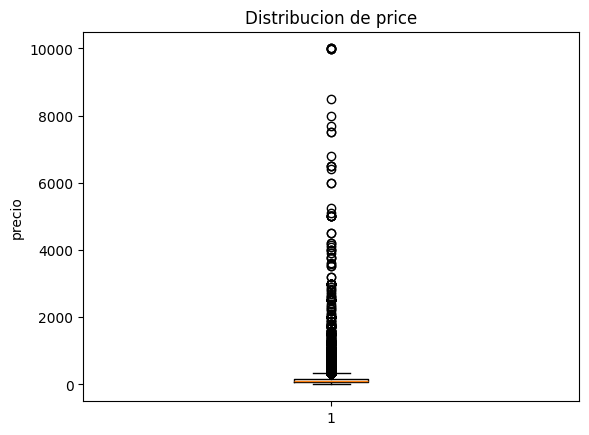

In [23]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).
plt.boxplot(df["price"])
plt.title("Distribucion de price")
plt.ylabel("precio")
plt.show()



**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

_Tu respuesta:_Lo que vi en el histograma, es que habia un grupo que tenia una frecuencia mayor de 40,000 pero un precio muy bajo lo que indica que la mayoria de datos corresponde a este segmento pero no correspondia al outlier. Luego en el boxplot se aprecian que existen muchos valores por encima del Q3 cuyo precio es >1,000 y que probablemente sean atipicos. Esto demuestra que el/los outlier(s) pueden estar enmascarados en el histograma y las demas medidas de tendecia central, pero serán visible en el boxplot. En la asimetria ya se sabia que la cola era fuertemente positiva y estaba hacia la derecha, y en la curtosis, se comprobó que la desviacion era extremadamente pesada con una distribucion muy alejada del centro, como en este caso, hacia el valor maximo.

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Tu respuesta:_Yo le diria que puede ser engañoso enfocarse solo en la media porque los valores pueden presentar una distribucion asimetrica o valores extremos. Le aconsejaria que lo primero que haga es ver la relacion entre media y mediana, ya que si hay mucha diferencia, es signo de asimetria. En caso de encontrar eso, le aconsejaria realizar las medidas de forma, como asimetria y curtosis para tener una idea mas clara de la distribucion de densidad de los datos en su dataset y si hay outliers que deben ser considerados para el analisis.

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |